IT25101588_Class_Balancing
UDITHA BANUKA — Individual Preprocessing Component

Technique: Class Imbalance Handling — Hybrid Resampling (Under-sampling + SMOTE + Tomek-Link Cleaning)

Why plain oversampling is not appropriate here
Member 5's feature engineering left 20 clean, non-leaking features, but the target
(`diabetes_stage_encoded`) is extremely imbalanced across all 5 classes:
`Type 2` (46,530), `Pre-Diabetes` (24,810), `No Diabetes` (6,190), `Gestational` (214), and
`Type 1` (94) — measured on the training split. Plain SMOTE oversampling every minority class
up to the majority count (46,530) would mean generating ~495 synthetic neighbors for every
single real `Type 1` patient. With only 94 original points to interpolate between, that many
synthetic copies mostly repeats a handful of directions in feature space and manufactures
false confidence rather than real signal — a well-known failure mode of naive SMOTE on
extremely rare classes.

Decision: drop `Type 1`, then hybrid-balance the remaining 4 classes
`Type 1` has too few samples (94) to synthesize reliably even with hybrid techniques, and it
already contributes almost nothing to the KNN baseline's minority-class recall in earlier
runs. It is dropped here (a documented, deliberate trade-off) so that resampling effort is
spent where it can actually produce trustworthy synthetic data. The remaining 4 classes are
then balanced using a hybrid strategy instead of pure oversampling:
1. **Random under-sampling** — trim the majority class (`Type 2`) down to a moderate target
   count instead of using its full size as the balancing target.
2. **SMOTE** — oversample the minority classes (`No Diabetes`, `Gestational`) up to that same
   moderate target, so no class needs an extreme multiplication factor.
3. **Tomek-link cleaning** — after resampling, remove borderline/overlapping sample pairs
   between classes, which sharpens the decision boundary instead of just rebalancing counts.

This keeps every class close to the same size without asking SMOTE to manufacture hundreds of
synthetic points per real minority example.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

In [2]:
df = pd.read_csv('../results/outputs/stage5_feature_engineered.csv')
print(df.shape)

(97297, 21)


In [3]:
target_col = 'diabetes_stage_encoded'
labels_full = {0: 'No Diabetes', 1: 'Pre-Diabetes', 2: 'Gestational', 3: 'Type 2', 4: 'Type 1'}
print(df[target_col].value_counts().sort_index().rename(index=labels_full))

diabetes_stage_encoded
No Diabetes      7737
Pre-Diabetes    31013
Gestational       267
Type 2          58163
Type 1            117
Name: count, dtype: int64


Step 1 — Drop the class that is too rare to resample reliably (`Type 1`)

In [4]:
df_bal = df[df[target_col] != 4].reset_index(drop=True)
print(df_bal.shape)

(97180, 21)


In [5]:
X = df_bal.drop(columns=[target_col])
y = df_bal[target_col]

labels = ['No Diabetes', 'Pre-Diabetes', 'Gestational', 'Type 2']
print(f"Dropped 'Type 1' ({(df[target_col] == 4).sum()} rows). Remaining shape: {df_bal.shape}")
print(y.value_counts().sort_index().rename(index=labels_full))

Dropped 'Type 1' (117 rows). Remaining shape: (97180, 21)
diabetes_stage_encoded
No Diabetes      7737
Pre-Diabetes    31013
Gestational       267
Type 2          58163
Name: count, dtype: int64


Step 2 — Train/test split *before* any resampling

As with any resampling technique, this is done on the training split only — the test set
stays in its original, untouched, imbalanced form so evaluation reflects real-world class
proportions.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (77744, 20)  Test shape: (19436, 20)


In [7]:
train_before = y_train.value_counts().sort_index()
print("\nTraining class distribution before balancing:")
print(train_before.rename(index=labels_full))


Training class distribution before balancing:
diabetes_stage_encoded
No Diabetes      6190
Pre-Diabetes    24810
Gestational       214
Type 2          46530
Name: count, dtype: int64


Step 3 — Hybrid resampling: under-sample the majority, then SMOTE + Tomek-link clean the minorities

The balancing target is set to the size of the **second-largest** class (`Pre-Diabetes`)
rather than the true majority (`Type 2`). `Type 2` is trimmed down to that target with random
under-sampling; `No Diabetes` and `Gestational` are then brought up to it with SMOTE, and
`SMOTETomek` removes any Tomek-link pairs (bordering points from different classes sitting
unusually close together) created in the process. This keeps the multiplication factor for
the rarest surviving class (`Gestational`, 214 real rows) to roughly 100x instead of the 200x+
it would need to reach the true majority count.

In [8]:
target_n = int(train_before.loc[1])  # size of the 2nd-largest class (Pre-Diabetes)
print("Balancing target per class:", target_n)

# 1) trim the majority class down to the target
under = RandomUnderSampler(sampling_strategy={3: target_n}, random_state=42)
X_under, y_under = under.fit_resample(X_train, y_train)

# 2) SMOTE the minority classes up to the target, then clean overlapping Tomek-link pairs
smote_tomek = SMOTETomek(
    sampling_strategy={0: target_n, 2: target_n},
    random_state=42
)
X_train_bal, y_train_bal = smote_tomek.fit_resample(X_under, y_under)

train_after = y_train_bal.value_counts().sort_index()
print("\nTraining class distribution after under-sampling + SMOTE + Tomek cleaning:")
print(train_after.rename(index=labels_full))
print(f"\nTraining rows: {X_train.shape[0]} -> {X_train_bal.shape[0]}")
print("Test set is untouched:", X_test.shape)

Balancing target per class: 24810

Training class distribution after under-sampling + SMOTE + Tomek cleaning:
diabetes_stage_encoded
No Diabetes     24803
Pre-Diabetes    22980
Gestational     24810
Type 2          22987
Name: count, dtype: int64

Training rows: 77744 -> 95580
Test set is untouched: (19436, 20)


EDA Visualization — Class distribution before vs after hybrid balancing (training split only)

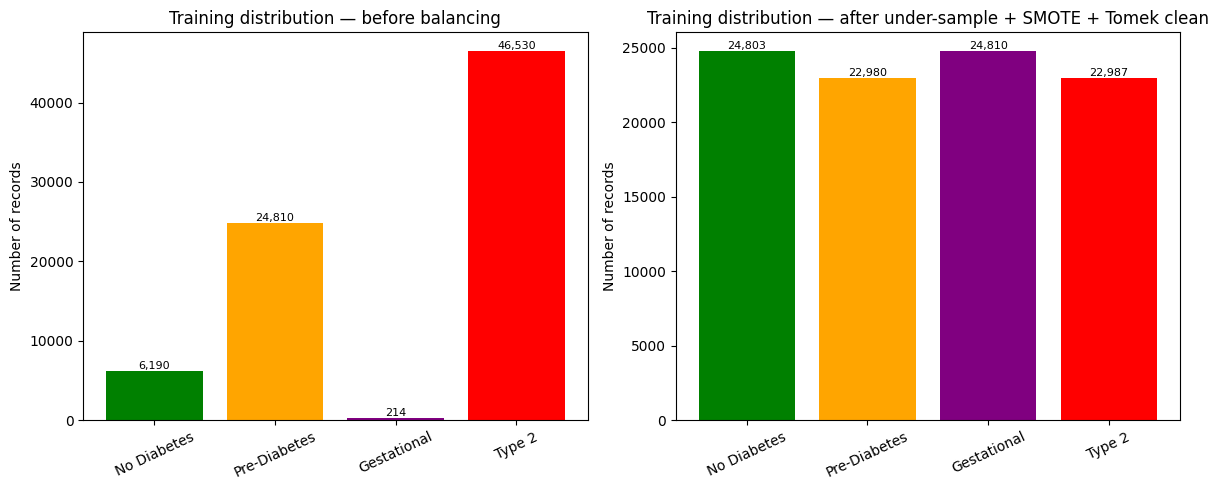

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['green', 'orange', 'purple', 'red']

axes[0].bar(labels, train_before.reindex([0,1,2,3]).values, color=colors)
axes[0].set_title('Training distribution — before balancing')
axes[0].set_ylabel('Number of records')
axes[0].tick_params(axis='x', rotation=25)
for i, v in enumerate(train_before.reindex([0,1,2,3]).values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)

axes[1].bar(labels, train_after.reindex([0,1,2,3]).values, color=colors)
axes[1].set_title('Training distribution — after under-sample + SMOTE + Tomek clean')
axes[1].set_ylabel('Number of records')
axes[1].tick_params(axis='x', rotation=25)
for i, v in enumerate(train_after.reindex([0,1,2,3]).values):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../results/eda_visualizations/class_balance_before_after.png', dpi=120)
plt.show()

Interpretation
Before balancing, `Type 2` and `Pre-Diabetes` dominate the training split while
`Gestational` (214 rows) is a tiny sliver by comparison. After the hybrid step, all four
remaining classes sit close to the same size (~23,000–25,000 rows each): `Type 2` was
**trimmed down** rather than left as the ceiling for everyone else, `No Diabetes` and
`Gestational` were oversampled with SMOTE to reach that same level, and Tomek-link cleaning
then removed a small number of ambiguous, closely-overlapping pairs between classes —
visible as the counts landing slightly under the exact target rather than precisely at it.
Compared to matching straight to the majority class, `Gestational` needed roughly 100x
synthetic growth here instead of 200x+, which keeps the synthetic points closer to genuinely
representative of the minority class's real feature space rather than dense repeats of a few
directions. `Type 1` was dropped rather than force-balanced from only 94 real examples — a
deliberate scope trade-off worth raising in the viva discussion.

Step 4 — Save the balanced training set and the held-out test set as checkpoints

In [10]:
train_balanced_df = X_train_bal.copy()
train_balanced_df[target_col] = y_train_bal.values
train_balanced_df.to_csv('../results/outputs/stage6_train_balanced.csv', index=False)

test_df = X_test.copy()
test_df[target_col] = y_test.values
test_df.to_csv('../results/outputs/stage6_test_holdout.csv', index=False)

print("Saved balanced training set:", train_balanced_df.shape)
print("Saved untouched test set (Type 1 excluded, 4 classes):", test_df.shape)

Saved balanced training set: (95580, 21)
Saved untouched test set (Type 1 excluded, 4 classes): (19436, 21)


Step 5 — Decision for the group pipeline

`Type 1` is dropped from the modeling target from this stage onward (both train and test),
so the group's baseline KNN model going forward predicts among the 4 remaining diabetes
stages. The balanced training set (`stage6_train_balanced.csv`) is what the model trains on;
the untouched, still-imbalanced test set (`stage6_test_holdout.csv`) is what it is evaluated
against, which keeps the reported accuracy honest and representative of real-world class
proportions.

Conclusion
- The target was confirmed to be severely imbalanced across all 5 classes, with `Type 1`
  (94 training rows) too rare to resample without manufacturing near-duplicate synthetic data.
- `Type 1` was dropped as a deliberate, documented trade-off; the remaining 4 classes were
  balanced with a **hybrid** technique — random under-sampling of the majority class, SMOTE
  oversampling of the minorities, and Tomek-link cleaning — rather than plain SMOTE-to-majority.
- This brought all 4 classes to a comparable size (~23k–25k rows) using a moderate,
  second-largest-class target instead of the full majority count, keeping synthetic-growth
  factors far lower for the rarest surviving class (`Gestational`).
- The test split was left untouched throughout, so downstream model evaluation remains
  representative of the real, imbalanced clinical population.